In [1]:
import os
import feature_selection as fs
import pandas as pd
import model as m
import numpy as np
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

2024-09-25 15:07:44.596770: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-09-25 15:07:44.598506: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2024-09-25 15:07:44.626669: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-09-25 15:07:44.626697: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-09-25 15:07:44.627360: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

# Data distribution


# Feature selection by subsets


## Functions

In [2]:

def get_age_distribution(ages, q_ranges=None, age_ranges=None):

    # Calculate quartiles
    if q_ranges:
        quartiles = np.percentile(ages, q_ranges)
        print(quartiles)
        # Define age groups based on quartiles
        quartile_ranges = [18] + quartiles.tolist() + [90]

        # Define age groups based on quartiles
    if age_ranges:
        quartile_ranges = age_ranges
    
    if age_ranges is None and q_ranges is None:
        raise ValueError('Either age_ranges or quartile_ranges must be provided')
    
    age_groups = [{'label': f'{int(quartile_ranges[i])}-{int(quartile_ranges[i+1])}', 
                    'range': (quartile_ranges[i], quartile_ranges[i+1]),
                    'count' : len([age for age in ages if (age > quartile_ranges[i]) and (age <= quartile_ranges[i+1])])
                    } for i in range(len(quartile_ranges)-1)]
    return age_groups
# Function to assign age group labels
def assign_age_group(age, age_groups):
    for group in age_groups:
        if group['range'][0] <= age < group['range'][1]:
            return group['label']
    return 'Unknown'


In [3]:
def get_feature_from_class(dataset, alpha=0.1):
    section_df = dataset.drop(columns=["Age"])
    section_df_age = dataset["Age"]
    section_df = m.remove_non_numeric_columns(section_df)
    features, coef = fs.ridge_L2(X=section_df, y=section_df_age, alpha=alpha)
    result = pd.DataFrame(list(features), coef, columns=["coef"])
    result["abs_coef"]=result["coef"].abs()
    result.sort_values(ascending=False, inplace=True, by="abs_coef")
    result
    return result

In [4]:
def get_feature_randomforest(dataset, n_bootstrap=100):
    section_df = dataset.drop(columns=["Age"])
    #section_df_age = dataset["Age"]
    # Define the category labels
    is_numeric = dataset["Age"].dtype.name in ["int64", "float64"]


    if is_numeric:
        labels = ['Young', 'MiddleAge', 'Old']
        # Define the age ranges for each category
        bins = [18, 35, 65, float('inf')]
        # Map the age numeric value to category label
        section_df_age = pd.cut(dataset['Age'], bins=bins, labels=labels, right=False)
    else:
        section_df_age = dataset["Age"]
    
    

    # Print the updated dataset
    section_df = m.remove_non_numeric_columns(section_df)
    coef = fs.random_forest(X=section_df, y=section_df_age, n_bootstrap=n_bootstrap)
    features = section_df.columns
    result = pd.DataFrame(list(features), coef, columns=["coef"])
    result.sort_values(ascending=False, inplace=True, by="coef")
    result
    return result

In [5]:
def get_feature_SMOTE(dataset, alpha=0.1, is_categorical=False):
    section_df = dataset.drop(columns=["Age"])
    if not is_categorical:
        labels = ['Young', 'MiddleAge', 'Old']
        # Define the age ranges for each category
        bins = [18, 35, 65, float('inf')]
        # Map the age numeric value to category label
        section_df_age = pd.cut(dataset['Age'], bins=bins, labels=labels, right=False)
    else:
        section_df_age = dataset["Age"]
    #section_df_age = pd.cut(dataset['Age'], bins=bins, labels=labels, right=False)
    section_df = m.remove_non_numeric_columns(section_df)
    features, coef = fs.smote(X=section_df, y=section_df_age)
    #result = pd.DataFrame(list(features), coef, columns=["coef"])
    ##result["abs_coef"]=result["coef"].abs()
    #result.sort_values(ascending=False, inplace=True, by="abs_coef")
    #result
    return features, coef

In [6]:
def get_feature_catBoost(dataset, is_categorical=True):
    section_df = dataset.drop(columns=["Age"])
    if not is_categorical:
        labels = ['Young', 'MiddleAge', 'Old']
        # Define the age ranges for each category
        bins = [18, 35, 65, float('inf')]
        # Map the age numeric value to category label
        section_df_age = pd.cut(dataset['Age'], bins=bins, labels=labels, right=False)
    else:
        section_df_age = dataset["Age"]
    #section_df_age = pd.cut(dataset['Age'], bins=bins, labels=labels, right=False)
    section_df = m.remove_non_numeric_columns(section_df)
    features, coef = fs.catBoost(X=section_df, y=section_df_age)
    #result = pd.DataFrame(list(features), coef, columns=["coef"])
    ##result["abs_coef"]=result["coef"].abs()augmented_data
    #result.sort_values(ascending=False, inplace=True, by="abs_coef")
    #result
    result = pd.DataFrame(list(features), coef, columns=["coef"])
    result.sort_values(ascending=False, inplace=True, by="coef")
    result
    return result


In [7]:

def plot_fake_data(result):
    # Assuming your DataFrame is named df
    # Perform dimensionality reduction
    X = result.drop(columns=["Age", "Class"]).values  # Extracting only numeric columns
    y_age = result["Age"].values
    y_class = result["Class"].values

    # Dimensionality reduction with PCA
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    # Dimensionality reduction with t-SNE
    tsne = TSNE(n_components=2, perplexity=10, random_state=30)
    X_tsne = tsne.fit_transform(X)
    color_map = {'Young': 'blue', 'MiddleAge': 'green', 'Old': 'red'}

    # Plotting
    plt.figure(figsize=(14, 7))

    # Plotting PCA
    plt.subplot(1, 2, 1)
    for i, age in enumerate(y_age):
        if y_class[i] == 'modified':
            marker = 'o'  # Circle for fake
        else:
            marker = 's'  # Square for real
        plt.scatter(X_pca[i, 0], X_pca[i, 1], c=color_map[age], marker=marker)
    plt.title('PCA')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')

    # Plotting t-SNE
    plt.subplot(1, 2, 2)
    for i, age in enumerate(y_age):
        if y_class[i] == 'modified':
            marker = 'o'  # Circle for fake
        else:
            marker = 's'  # Square for real
        plt.scatter(X_tsne[i, 0], X_tsne[i, 1], c=color_map[age], marker=marker)
    plt.title('t-SNE')
    plt.xlabel('t-SNE Dimension 1')
    plt.ylabel('t-SNE Dimension 2')

    plt.tight_layout()
    plt.show()


## RNAseq data

### see distribution

In [6]:
all_rna_seq_data = pd.read_csv("Data/RNAseq_All_abundances_adjusted.csv")

In [7]:
all_rna_seq_data["Age"].describe()

count    270.000000
mean      53.384444
std       22.386252
min       18.000000
25%       27.500000
50%       65.500000
75%       71.000000
max       92.000000
Name: Age, dtype: float64

In [28]:
age_ranges = get_age_distribution(all_rna_seq_data["Age"], q_ranges=[100/6, 200/6, 300/6, 400/6, 500/6])
age_ranges
age_ranges = get_age_distribution(all_rna_seq_data["Age"], age_ranges=[18, 26, 35, 65, 70, 72, 95])
age_ranges

[26.  33.  65.5 71.  72. ]


[{'label': '18-26', 'range': (18, 26), 'count': 46},
 {'label': '26-35', 'range': (26, 35), 'count': 46},
 {'label': '35-65', 'range': (35, 65), 'count': 42},
 {'label': '65-70', 'range': (65, 70), 'count': 17},
 {'label': '70-72', 'range': (70, 72), 'count': 76},
 {'label': '72-95', 'range': (72, 95), 'count': 42}]

In [29]:
age_ranges

[{'label': '18-26', 'range': (18, 26), 'count': 46},
 {'label': '26-35', 'range': (26, 35), 'count': 46},
 {'label': '35-65', 'range': (35, 65), 'count': 42},
 {'label': '65-70', 'range': (65, 70), 'count': 17},
 {'label': '70-72', 'range': (70, 72), 'count': 76},
 {'label': '72-95', 'range': (72, 95), 'count': 42}]

<Figure size 1000x600 with 0 Axes>

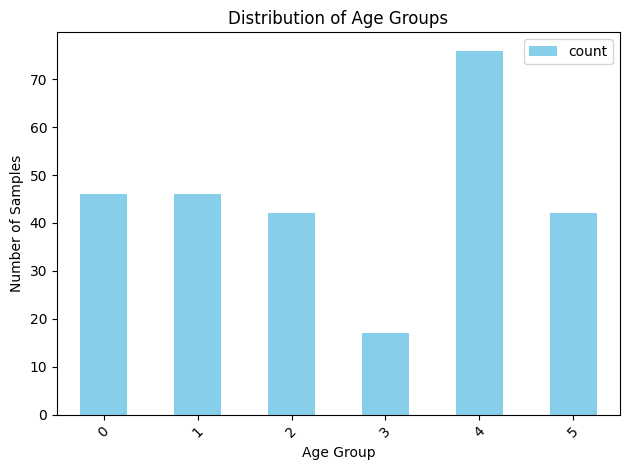

In [30]:
plt.figure(figsize=(10, 6))
pd.DataFrame(age_ranges).plot(kind='bar', color='skyblue')
plt.title('Distribution of Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

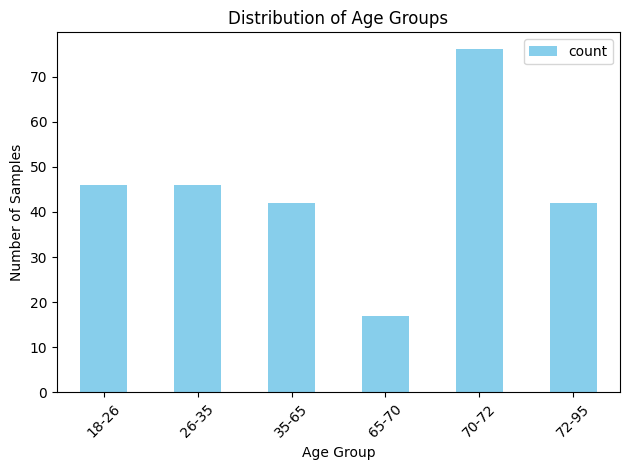

In [31]:
plt.figure(figsize=(10, 6))
pd.DataFrame(age_ranges).plot(kind='bar', color='skyblue')
plt.title('Distribution of Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Number of Samples')

# Add custom x-tick labels
plt.xticks(range(len(age_ranges)), [group['label'] for group in age_ranges], rotation=45)

plt.tight_layout()
plt.savefig('Results/age_distribution_divided.png')

plt.show()


In [25]:
age_ranges = get_age_distribution(all_rna_seq_data["Age"], age_ranges=[18, 35,65,95])
age_ranges

[{'label': '18-35', 'range': (18, 35), 'count': 92},
 {'label': '35-65', 'range': (35, 65), 'count': 42},
 {'label': '65-95', 'range': (65, 95), 'count': 135}]

<Figure size 1000x600 with 0 Axes>

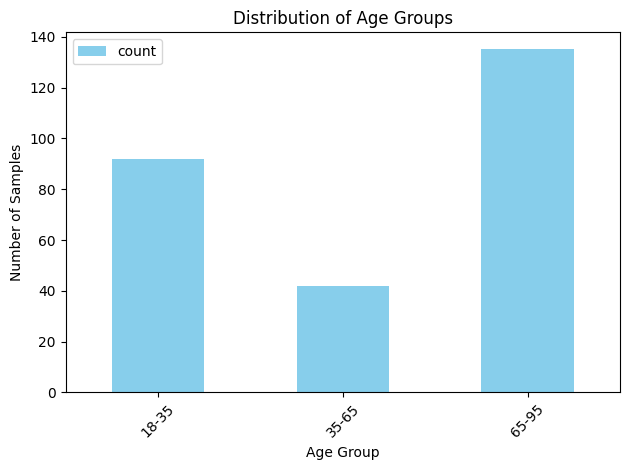

In [27]:
x_labels = [age['label'] for age in age_ranges]

plt.figure(figsize=(10, 6))
pd.DataFrame(age_ranges).plot(kind='bar', xticks=range(len(age_ranges)), color='skyblue')
plt.title('Distribution of Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Number of Samples')
plt.xticks(range(len(age_ranges)), x_labels, rotation=45)  # Setting x-tick labels
plt.tight_layout()
plt.savefig('Results/age_distribution_original.png')
plt.show()

### Augment data: SMOTE

Now lets run the SMOTE on all with this change


In [32]:
# Assign age group labels on the dataframe all_rna_seq_data
all_rna_seq_data['AgeGroup'] = all_rna_seq_data['Age'].apply(lambda x: assign_age_group(x, age_ranges))
all_rna_seq_data['AgeGroup'].value_counts()

AgeGroup
70-72    72
26-35    49
72-95    48
18-26    42
35-65    42
65-70    17
Name: count, dtype: int64

In [33]:
all_rna_seq_data[all_rna_seq_data['AgeGroup'] == 'Unknown']

,Sample,ENSG00000000003.14,ENSG00000000005.5,ENSG00000000419.12,ENSG00000000457.13,ENSG00000000460.16,ENSG00000000938.12,ENSG00000000971.15,ENSG00000001036.13,ENSG00000001084.11,...,ENSG00000285472.1,ENSG00000285476.1,ENSG00000285480.1,ENSG00000285491.1,ENSG00000285505.1,ENSG00000285508.1,ENSG00000285509.1,Experiment,Age,AgeGroup


In [34]:
all_rna_seq_data[all_rna_seq_data['Age'] == 71]

,Sample,ENSG00000000003.14,ENSG00000000005.5,ENSG00000000419.12,ENSG00000000457.13,ENSG00000000460.16,ENSG00000000938.12,ENSG00000000971.15,ENSG00000001036.13,ENSG00000001084.11,...,ENSG00000285472.1,ENSG00000285476.1,ENSG00000285480.1,ENSG00000285491.1,ENSG00000285505.1,ENSG00000285508.1,ENSG00000285509.1,Experiment,Age,AgeGroup
51,SRR12604092,-0.028414,-0.032553,-0.001362,-0.028270,-0.029386,-0.032315,-0.027363,-0.028447,-0.024889,...,-0.032598,-0.032513,-0.031188,-0.032593,-0.032616,-0.029468,-0.032476,GSE157585,71.0,70-72
52,SRR12604093,-0.027196,-0.031684,-0.001005,-0.029161,-0.029152,-0.031145,-0.022870,-0.028542,-0.023569,...,-0.031728,-0.031280,-0.030700,-0.031722,-0.031747,-0.028999,-0.031495,GSE157585,71.0,70-72
53,SRR12604094,-0.034920,-0.042705,0.004298,-0.040615,-0.039852,-0.034149,-0.013498,-0.026710,-0.035774,...,-0.043056,-0.042699,-0.041665,-0.043058,-0.043063,-0.038163,-0.043014,GSE157585,71.0,70-72
54,SRR12604095,-0.029693,-0.036244,0.001706,-0.031493,-0.032993,-0.034651,-0.019780,-0.028186,-0.029091,...,-0.036292,-0.036199,-0.034652,-0.036289,-0.036305,-0.035053,-0.036094,GSE157585,71.0,70-72
55,SRR12604096,-0.030995,-0.034490,-0.000125,-0.031148,-0.032214,-0.033802,-0.023980,-0.029320,-0.028017,...,-0.034536,-0.034217,-0.032701,-0.034532,-0.034552,-0.033282,-0.034315,GSE157585,71.0,70-72
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
168,SRR13759017,-0.025362,-0.027671,-0.004946,-0.027212,-0.026399,-0.029140,-0.020285,-0.024762,-0.022192,...,-0.030116,-0.030048,-0.029365,-0.030107,-0.030118,-0.022769,-0.029949,GSE167186,71.0,70-72
179,SRR13759028,-0.027086,-0.026545,-0.004039,-0.024437,-0.024524,-0.025908,-0.019950,-0.018388,-0.019579,...,-0.026466,-0.026384,-0.023295,-0.026459,-0.026490,-0.017526,-0.026295,GSE167186,71.0,70-72
185,SRR13759035,-0.025292,-0.025434,-0.004559,-0.023290,-0.023826,-0.024961,-0.018965,-0.019622,-0.020224,...,-0.025395,-0.025310,-0.025276,-0.025390,-0.025427,-0.028962,-0.025224,GSE167186,71.0,70-72
187,SRR13759037,-0.021256,-0.025461,-0.003651,-0.023643,-0.023849,-0.024983,-0.019143,-0.020970,-0.019655,...,-0.025421,-0.025335,-0.021488,-0.025415,-0.025452,-0.022961,-0.025250,GSE167186,71.0,70-72


In [35]:
# Run SMOTE with Age
dataset = all_rna_seq_data.copy()
dataset["Age"]=dataset["AgeGroup"]
dataset = dataset.drop(columns=["AgeGroup"])
result = get_feature_SMOTE(dataset, is_categorical=True)
#split the "Age" from result by "-" and replace it with the median of those two values
result

Class distribution before SMOTE: Counter({'70-72': 72, '26-35': 49, '72-95': 48, '18-26': 42, '35-65': 42, '65-70': 17})
Class distribution after SMOTE: Counter({'18-26': 72, '26-35': 72, '35-65': 72, '65-70': 72, '72-95': 72, '70-72': 72})


(     ENSG00000000003.14  ENSG00000000005.5  ENSG00000000419.12  \
 0             -0.025109          -0.028258           -0.005872   
 1             -0.026260          -0.033508           -0.004524   
 2             -0.030608          -0.037952           -0.002987   
 3             -0.021728          -0.024309           -0.004225   
 4             -0.019503          -0.034629           -0.004944   
 ..                  ...                ...                 ...   
 427           -0.023808          -0.022515           -0.004636   
 428           -0.025550          -0.030576           -0.003855   
 429           -0.023858          -0.028191           -0.005262   
 430           -0.025140          -0.028533           -0.003707   
 431           -0.027327          -0.027878           -0.004412   
 
      ENSG00000000457.13  ENSG00000000460.16  ENSG00000000938.12  \
 0             -0.026729           -0.026472           -0.027634   
 1             -0.028312           -0.031995           -0.

In [36]:
result[0]["Age"]= result[1]
result_df = result[0]

/tmp/ipykernel_26555/904783035.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  result[0]["Age"]= result[1]


In [37]:
# get the mean between the two values
result_df["Age"].str.split("-").apply(lambda x: (int(x[0])+int(x[1]))/2)

0      22.0
1      30.5
2      30.5
3      30.5
4      50.0
       ... 
427    83.5
428    83.5
429    83.5
430    83.5
431    83.5
Name: Age, Length: 432, dtype: float64

In [38]:

result_df["Age"] = result_df["Age"].str.split("-").apply(lambda x: (int(x[0])+int(x[1]))/2)

result_df["Age"].describe()

count    432.000000
mean      54.083333
std       22.137883
min       22.000000
25%       30.500000
50%       58.750000
75%       71.000000
max       83.500000
Name: Age, dtype: float64

### Ridge L2

In [39]:
result_df.to_csv("Results/master/augmented_data/RNAseq/SMOTE/All_samples_special_divition.csv")


In [ ]:
# from folder Data/divided/RNA get all the files and put them in a list
file_list = os.listdir("Data/divided_datasets/RNAseq")


In [ ]:
# For each file in the list, do get_feature_from_class and save the result in a file
for file in file_list:
    dataset = pd.read_csv("Data/divided_datasets/RNAseq/"+file)
    result = get_feature_from_class(dataset)
    result.to_csv("Results/feature_selection/RNAseq/"+file.split(".")[0]+"_feature_selection.csv")
    print("Done with", file)

Done with Sex_female.csv
Done with Sex_male.csv
Done with Status_untrained.csv
Done with Experiment_GSE167186.csv
Done with Experiment_GSE152558.csv
Done with Experiment_GSE129643.csv
Done with Status_Sarcopenia.csv
Done with Experiment_GSE164471.csv
Done with Status_Healthy.csv
Done with Experiment_GSE60590.csv
Done with Status_trained.csv
Done with Experiment_GSE157585.csv


In [ ]:
# For each file in the list, do get_feature_from_class and save the result in a file
for file in file_list:
    dataset = pd.read_csv("Data/divided_datasets/RNAseq/"+file)
    result = get_feature_from_class(dataset)
    result.to_csv("Results/feature_selection/RNAseq/"+file.split(".")[0]+"_feature_selection.csv")
    print("Done with", file)

### CatBoost

In [ ]:
file_list = os.listdir("Data/divided_datasets/RNAseq")
file_list

['Sex_female.csv',
 'Sex_male.csv',
 'Status_untrained.csv',
 'Experiment_GSE167186.csv',
 'Experiment_GSE152558.csv',
 'Experiment_GSE129643.csv',
 'Status_Sarcopenia.csv',
 'Experiment_GSE164471.csv',
 'Status_Healthy.csv',
 'Experiment_GSE60590.csv',
 'Status_trained.csv',
 'Experiment_GSE157585.csv']

In [ ]:
for file in file_list:
    dataset = pd.read_csv("Data/divided_datasets/RNAseq/"+file)
    result = get_feature_catBoost(dataset)
    result["abs_coef"]=result["coef"].abs()
    result.to_csv("Results/feature_selection/RNAseq/"+file.split(".")[0]+"_feature_selection.csv")
    print("Done with", file)

Done with Sex_female.csv
Done with Sex_male.csv
Done with Status_untrained.csv
Done with Experiment_GSE167186.csv
Done with Experiment_GSE152558.csv
Done with Experiment_GSE129643.csv
Done with Status_Sarcopenia.csv
Done with Experiment_GSE164471.csv
Done with Status_Healthy.csv
Done with Experiment_GSE60590.csv
Done with Status_trained.csv
Done with Experiment_GSE157585.csv


In [ ]:
result

(array([0., 0., 0., ..., 0., 0., 0.]),
 Index(['ENSG00000000003.14', 'ENSG00000000005.5', 'ENSG00000000419.12',
        'ENSG00000000457.13', 'ENSG00000000460.16', 'ENSG00000000938.12',
        'ENSG00000000971.15', 'ENSG00000001036.13', 'ENSG00000001084.11',
        'ENSG00000001167.14',
        ...
        'ENSG00000285458.1', 'ENSG00000285470.1', 'ENSG00000285471.1',
        'ENSG00000285472.1', 'ENSG00000285476.1', 'ENSG00000285480.1',
        'ENSG00000285491.1', 'ENSG00000285505.1', 'ENSG00000285508.1',
        'ENSG00000285509.1'],
       dtype='object', length=34505))

### All to one file

In [ ]:
file = "RNAseq_All_abundances_adjusted.csv"

dataset = pd.read_csv("/home/karen/Documents/phd/Data/Batch_corrected/RNAseq_abundances_adjusted_recombat.csv")
result = get_feature_randomforest(dataset)
result.to_csv("Results/feature_selection/RNAseq/random_forest_0/"+file.split(".")[0]+"_feature_selection.csv")
result = get_feature_from_class(dataset)
result.to_csv("Results/feature_selection/RNAseq/ridge_L2_0/"+file.split(".")[0]+"_feature_selection.csv")
print("Done with", file)

Selected Features: [35, 43, 46, 66, 76, 167, 192, 207, 221, 245, 246, 268, 299, 325, 328, 329, 371, 433, 434, 459, 482, 491, 494, 499, 507, 583, 612, 666, 762, 764, 851, 902, 930, 931, 953, 1014, 1028, 1040, 1043, 1054, 1075, 1087, 1099, 1116, 1128, 1150, 1172, 1180, 1207, 1208, 1216, 1240, 1246, 1265, 1288, 1304, 1340, 1360, 1371, 1374, 1385, 1391, 1454, 1520, 1531, 1553, 1573, 1576, 1634, 1642, 1661, 1667, 1688, 1709, 1726, 1748, 1764, 1803, 1811, 1818, 1915, 1984, 2020, 2040, 2129, 2150, 2177, 2216, 2252, 2296, 2311, 2315, 2329, 2368, 2384, 2393, 2398, 2431, 2449, 2467, 2530, 2552, 2565, 2585, 2603, 2643, 2659, 2666, 2766, 2768, 2785, 2786, 2811, 2827, 2843, 2860, 2912, 2921, 2924, 2948, 3022, 3024, 3068, 3070, 3074, 3092, 3096, 3116, 3139, 3148, 3187, 3237, 3289, 3299, 3323, 3349, 3351, 3356, 3392, 3415, 3438, 3454, 3457, 3574, 3577, 3607, 3618, 3629, 3647, 3650, 3673, 3715, 3795, 3801, 3846, 3848, 3873, 3885, 3899, 3914, 3932, 3955, 3972, 3988, 3992, 4009, 4064, 4066, 4108, 4124, 

Done with RNAseq_All_abundances_adjusted.csv


In [ ]:
for file in file_list:
    try:
        dataset = pd.read_csv("Data/divided_datasets/RNAseq/"+file)
        features, ages = get_feature_SMOTE(dataset)
        features["Age"]=ages
        original = m.remove_non_numeric_columns(dataset)
        original["Class"]=["original"]*len(original)
        features["Class"]=["modified"]*len(features)

        result = pd.concat([original, features])

        result.to_csv("Results/augmented_data/RNAseq/SMOTE/"+file.split(".")[0]+"_feature_selection.csv")
        print("Done with", file)
    except:
        print("Error with", file)
        continue


Class distribution before SMOTE: Counter({'Young': 25, 'MiddleAge': 15, 'Old': 5})
Error with Sex_female.csv
Class distribution before SMOTE: Counter({'Old': 42, 'MiddleAge': 27, 'Young': 26})
Class distribution after SMOTE: Counter({'Young': 42, 'MiddleAge': 42, 'Old': 42})


/tmp/ipykernel_25934/1570577223.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features["Age"]=ages
/tmp/ipykernel_25934/1570577223.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features["Class"]=["modified"]*len(features)


Done with Sex_male.csv
Class distribution before SMOTE: Counter({'Young': 12})
Error with Status_untrained.csv
Class distribution before SMOTE: Counter({'Old': 53, 'Young': 19, 'MiddleAge': 3})
Error with Experiment_GSE167186.csv
Class distribution before SMOTE: Counter({'MiddleAge': 3, 'Old': 2})
Error with Experiment_GSE152558.csv
Class distribution before SMOTE: Counter({'MiddleAge': 13, 'Young': 8, 'Old': 8})
Class distribution after SMOTE: Counter({'Young': 13, 'MiddleAge': 13, 'Old': 13})


/tmp/ipykernel_25934/1570577223.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features["Age"]=ages
/tmp/ipykernel_25934/1570577223.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features["Class"]=["modified"]*len(features)


Done with Experiment_GSE129643.csv
Class distribution before SMOTE: Counter({'Old': 23})
Error with Status_Sarcopenia.csv
Class distribution before SMOTE: Counter({'MiddleAge': 23, 'Young': 12, 'Old': 11})
Class distribution after SMOTE: Counter({'Young': 23, 'MiddleAge': 23, 'Old': 23})


...

Done with Experiment_GSE164471.csv
Class distribution before SMOTE: Counter({'Old': 110, 'Young': 60, 'MiddleAge': 42})
Class distribution after SMOTE: Counter({'Young': 110, 'MiddleAge': 110, 'Old': 110})


/tmp/ipykernel_25934/1570577223.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features["Age"]=ages
/tmp/ipykernel_25934/1570577223.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features["Class"]=["modified"]*len(features)


Done with Status_Healthy.csv
Class distribution before SMOTE: Counter({'Young': 31})
Error with Experiment_GSE60590.csv
Class distribution before SMOTE: Counter({'Young': 19})
Error with Status_trained.csv
Class distribution before SMOTE: Counter({'Old': 63, 'Young': 21})
Class distribution after SMOTE: Counter({'Old': 63, 'Young': 63})


/tmp/ipykernel_25934/1570577223.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features["Age"]=ages
/tmp/ipykernel_25934/1570577223.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features["Class"]=["modified"]*len(features)


Done with Experiment_GSE157585.csv


In [ ]:
file = "RNAseq_All_abundances_adjusted.csv"

dataset = pd.read_csv("Data/"+file)
features, ages = get_feature_SMOTE(dataset)
features["Age"]=ages
#original = m.remove_non_numeric_columns(dataset)
#original["Class"]=["original"]*len(original)
#features["Class"]=["modified"]*len(features)

result = features # pd.concat
([original, features])

result.to_csv("Results/augmented_data/RNAseq/SMOTE/"+file.split(".")[0]+"_feature_selection.csv")
print("Done with", file)

Class distribution before SMOTE: Counter({'Old': 137, 'Young': 91, 'MiddleAge': 42})
Class distribution after SMOTE: Counter({'Young': 137, 'MiddleAge': 137, 'Old': 137})


/tmp/ipykernel_25934/132899303.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features["Age"]=ages


Done with RNAseq_All_abundances_adjusted.csv


In [ ]:
result.columns

Index(['ENSG00000000003.14', 'ENSG00000000005.5', 'ENSG00000000419.12',
       'ENSG00000000457.13', 'ENSG00000000460.16', 'ENSG00000000938.12',
       'ENSG00000000971.15', 'ENSG00000001036.13', 'ENSG00000001084.11',
       'ENSG00000001167.14',
       ...
       'ENSG00000285471.1', 'ENSG00000285472.1', 'ENSG00000285476.1',
       'ENSG00000285480.1', 'ENSG00000285491.1', 'ENSG00000285505.1',
       'ENSG00000285508.1', 'ENSG00000285509.1', 'Age', 'Class'],
      dtype='object', length=34507)

In [ ]:
original = m.remove_non_numeric_columns(dataset)
original_age = dataset["Age"]
original.drop(columns=["Age"], inplace=True)
original["Class"]=["original"]*len(original)
features["Class"]=["modified"]*len(features)

both_df = pd.concat([original, features])
both_ages = pd.concat([original_age, ages])
classes_df = both_df["Class"]
both_df.drop(columns=["Class"], inplace=True)

/tmp/ipykernel_25934/1491029344.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features["Class"]=["modified"]*len(features)


In [ ]:
# replace all "young" with 10, "middle" with 50 and "old" with 80
result["Age"] = result["Age"].replace("Young", 10)
result["Age"] = result["Age"].replace("MiddleAge", 50)
result["Age"] = result["Age"].replace("Old", 80)
labels = ['Young', 'MiddleAge', 'Old']
# Define the age ranges for each category
bins = [18, 35, 65, float('inf')]
# Map the age numeric value to category label
result["Age"] = pd.cut(result['Age'], bins=bins, labels=labels, right=False)
result["Age"].value_counts()

/tmp/ipykernel_25934/2634729573.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  result["Age"] = result["Age"].replace("Old", 80)


Age
Old          274
MiddleAge    179
Young         91
Name: count, dtype: int64

In [ ]:
result["Class"].value_counts()

Class
modified    411
original    270
Name: count, dtype: int64

In [ ]:
plot_fake_data(result)

array([23.0, 28.0, 31.0, 31.0, 35.0, 38.0, 42.0, 45.0, 45.0, 51.0, 52.0,
       52.0, 57.0, 58.0, 60.0, 67.0, 67.0, 72.0, 73.0, 80.0, 81.0, 83.0,
       22.0, 25.0, 25.0, 26.0, 26.0, 27.0, 31.0, 33.0, 35.0, 37.0, 38.0,
       42.0, 47.0, 47.0, 52.0, 52.0, 54.0, 62.0, 63.0, 63.0, 72.0, 76.0,
       81.0, 81.0, 46.0, 43.0, 41.0, 85.0, 83.0, 71.0, 71.0, 71.0, 71.0,
       71.0, 71.0, 71.0, 71.0, 71.0, 71.0, 71.0, 71.0, 71.0, 71.0, 71.0,
       71.0, 71.0, 71.0, 71.0, 71.0, 71.0, 71.0, 71.0, 71.0, 71.0, 71.0,
       71.0, 71.0, 71.0, 71.0, 71.0, 71.0, 71.0, 71.0, 71.0, 71.0, 71.0,
       71.0, 71.0, 71.0, 71.0, 71.0, 71.0, 71.0, 71.0, 71.0, 71.0, 71.0,
       71.0, 71.0, 71.0, 71.0, 71.0, 71.0, 71.0, 71.0, 71.0, 71.0, 71.0,
       71.0, 71.0, 71.0, 71.0, 24.0, 24.0, 24.0, 24.0, 24.0, 24.0, 24.0,
       24.0, 24.0, 24.0, 24.0, 24.0, 24.0, 24.0, 24.0, 24.0, 24.0, 24.0,
       24.0, 24.0, 24.0, 91.0, 86.0, 69.0, 83.0, 71.0, 64.0, 81.0, 88.0,
       80.0, 82.0, 92.0, 78.0, 77.0, 70.0, 64.0, 69

## Microarray

Lets first get the categorical for all microarray

## Data

In [8]:
#all_microarray_data = pd.read_csv("Data/microarray_clean_status.csv")
#all_microarray_data = pd.read_csv("Data/microarray_abundances_adjusted_combat.csv")
all_microarray_data = pd.read_csv("Data/microarray_clean_reCombat.csv")
all_microarray_data["Age"].describe()

count    522.000000
mean      47.597184
std       15.269548
min       18.000000
25%       36.000000
50%       48.000000
75%       59.000000
max       83.560000
Name: Age, dtype: float64

In [9]:
age_ranges = get_age_distribution(all_microarray_data["Age"], q_ranges=[100/6, 200/6, 300/6, 400/6, 500/6])
age_ranges
#age_ranges = get_age_distribution(all_rna_seq_data["Age"], age_ranges=[18, 26, 33, 65, 70, 72, 95])
age_ranges

[29.         41.81333333 48.         54.         64.005     ]


[{'label': '18-29', 'range': (18, 29.0), 'count': 88},
 {'label': '29-41', 'range': (29.0, 41.81333333333334), 'count': 85},
 {'label': '41-48', 'range': (41.81333333333334, 48.0), 'count': 97},
 {'label': '48-54', 'range': (48.0, 54.0), 'count': 79},
 {'label': '54-64', 'range': (54.0, 64.005), 'count': 85},
 {'label': '64-90', 'range': (64.005, 90), 'count': 87}]

<Figure size 1000x600 with 0 Axes>

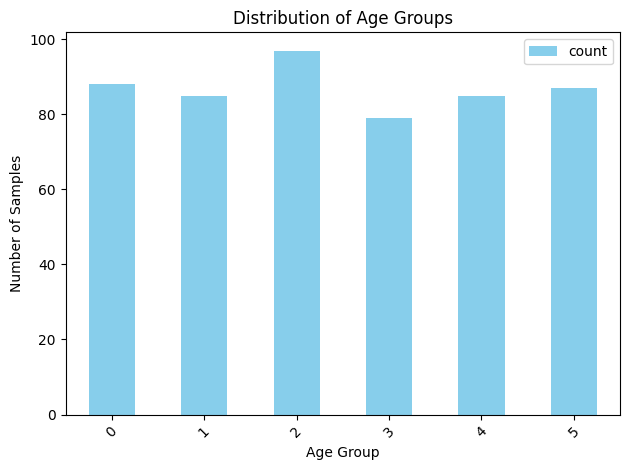

In [13]:
plt.figure(figsize=(10, 6))
pd.DataFrame(age_ranges).plot(kind='bar', color='skyblue')
plt.title('Distribution of Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Ridge L2

In [10]:
file_list = os.listdir("Data/divided_datasets/microarray")

In [11]:
# For each file in the list, do get_feature_from_class and save the result in a file
for file in file_list:
    dataset = pd.read_csv("Data/divided_datasets/microarray/"+file)
    result = get_feature_from_class(dataset)
    result.to_csv("Results/feature_selection/microarray/ridge_L2_0/"+file.split(".")[0]+"_feature_selection.csv")
    print("Done with", file)

Done with Status_Sedentary.csv
Done with Sex_Male.csv
Done with Status_nPOS.csv
Done with Sex_Female.csv
Done with Experiment_GSE38718.csv
Done with Experiment_GSE13070.csv
Done with Experiment_GSE674_2.csv
Done with Experiment_GSE47969.csv
Done with Experiment_GSE8157.csv
Done with Status_POS.csv
Done with Experiment_GSE9103.csv
Done with Experiment_GSE59880.csv
Done with Experiment_GSE6348.csv
Done with Experiment_GSE1428.csv
Done with Experiment_GSE48278.csv
Done with Experiment_GSE40551.csv
Done with Experiment_GSE161643.csv
Done with Status_Trained.csv
Done with Status_Obese.csv
Done with Status_Healthy.csv
Done with Experiment_GSE9676.csv
Done with Experiment_GSE87105.csv


In [17]:
dataset=all_microarray_data
normalize_dataset_columns = dataset.drop(columns=["Sample","Experiment"]).columns
normalize_dataset, arr_scaler = m.normalize_train_data(dataset.drop(columns=["Sample","Experiment"]))
normalize_dataset = pd.DataFrame(normalize_dataset, columns=normalize_dataset_columns)
normalize_dataset["Sample"]=dataset["Sample"]
normalize_dataset["Experiment"]=dataset["Experiment"]                                                       
result = get_feature_from_class(normalize_dataset)
result.to_csv("Results/feature_selection/microarray/ridge_L2_0/all_feature_selection_normalized.csv")

In [19]:
result

,coef,abs_coef
AW138371,-3.383607e-02,3.383607e-02
W52819,-3.208154e-02,3.208154e-02
BG911806,-2.708215e-02,2.708215e-02
AW291521,-2.298153e-02,2.298153e-02
AK093727,-2.115109e-02,2.115109e-02
...,...,...
D87328,1.890107e-07,1.890107e-07
AI140917,7.288826e-08,7.288826e-08
AF116601,-3.383015e-08,3.383015e-08
D49958,-1.733443e-08,1.733443e-08


### Smote

Time to run the SMOTE

In [14]:
# Assign age group labels on the dataframe all_rna_seq_data
all_microarray_data['AgeGroup'] = all_microarray_data['Age'].apply(lambda x: assign_age_group(x, age_ranges))
all_microarray_data['AgeGroup'].value_counts()

AgeGroup
54-64    94
29-41    90
64-90    87
41-48    86
18-29    84
48-54    81
Name: count, dtype: int64

In [11]:
# Run SMOTE with Age
dataset = all_microarray_data.copy()
dataset["Age"]=dataset["AgeGroup"]
dataset = dataset.drop(columns=["AgeGroup"])
result = get_feature_SMOTE(dataset, is_categorical=True)
#split the "Age" from result by "-" and replace it with the median of those two values
result

Class distribution before SMOTE: Counter({'50-52': 138, '59-90': 136, '18-35': 130, '35-45': 129, '52-59': 124, '45-50': 120})
Class distribution after SMOTE: Counter({'52-59': 138, '50-52': 138, '45-50': 138, '35-45': 138, '18-35': 138, '59-90': 138})


(       U48705    M87338    X51757    X69699    L36861    L13852    X55005  \
 0    0.495256  0.279388  0.803178  0.796755  0.157397  0.063780  0.960372   
 1    0.924375  0.170402  0.804129  0.775366  0.149248  0.120791  0.926952   
 2    0.570074  0.193924  0.804876  0.805559  0.160912  0.131781  0.921238   
 3    0.694998  0.253729  0.769925  0.702828  0.138010  0.049982  0.929471   
 4    0.463058  0.324250  0.866488  0.849856  0.166915  0.100732  0.961816   
 ..        ...       ...       ...       ...       ...       ...       ...   
 823  0.701674  0.310732  0.783441  0.774146  0.151736  0.121408  0.939766   
 824  0.426451  0.268390  0.799719  0.805160  0.155592  0.100189  0.966904   
 825  1.216172  0.266837  0.815194  0.759525  0.141122  0.050756  1.000737   
 826  0.726055  0.283816  0.790601  0.788625  0.132056  0.081346  0.941982   
 827  0.490855  0.262830  1.109084  1.128665  0.341435  0.124351  1.192945   
 
        X79510    M21121    J02843  ...  AW050627  AI654857   

In [12]:
result[0]["Age"]= result[1]
result_df = result[0]

/tmp/ipykernel_225935/904783035.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  result[0]["Age"]= result[1]


In [13]:
result_df["Age"].str.split("-").apply(lambda x: (int(x[0])+int(x[1]))/2)

0      55.5
1      51.0
2      55.5
3      55.5
4      51.0
       ... 
823    55.5
824    55.5
825    55.5
826    74.5
827    74.5
Name: Age, Length: 828, dtype: float64

In [14]:

result_df["Age"] = result_df["Age"].str.split("-").apply(lambda x: (int(x[0])+int(x[1]))/2)

result_df["Age"].describe()

count    828.000000
mean      49.166667
std       14.648027
min       26.500000
25%       40.000000
50%       49.250000
75%       55.500000
max       74.500000
Name: Age, dtype: float64

In [15]:
result_df.to_csv("Results/augmented_data/microarray/SMOTE/All_samples_special_divition_after_batch_correction_recombat.csv")


In [ ]:
path_str= "Data/divided_datasets/microarray/"
file_list = os.listdir(path_str)
# For each file in the list, do get_feature_from_class and save the result in a file



In [ ]:
for file in file_list:
    dataset = pd.read_csv(path_str+file)
    result = get_feature_from_class(dataset)
    result.to_csv("Results/feature_selection/microarray/"+file.split(".")[0]+"_feature_selection.csv")
    print("Done with", file)

Done with Status_Sedentary.csv
Done with Sex_Male.csv
Done with Status_nPOS.csv
Done with Sex_Female.csv
Done with Experiment_GSE38718.csv
Done with Experiment_GSE13070.csv
Done with Experiment_GSE674_2.csv
Done with Experiment_GSE47969.csv
Done with Experiment_GSE8157.csv
Done with Status_POS.csv
Done with Experiment_GSE9103.csv
Done with Experiment_GSE59880.csv
Done with Experiment_GSE6348.csv
Done with Experiment_GSE1428.csv
Done with Experiment_GSE48278.csv
Done with Experiment_GSE40551.csv
Done with Experiment_GSE161643.csv
Done with Status_Trained.csv
Done with Status_Obese.csv
Done with Status_Healthy.csv
Done with Experiment_GSE9676.csv
Done with Experiment_GSE87105.csv


In [ ]:
for file in file_list:
    dataset = pd.read_csv("Data/divided_datasets/microarray/"+file)
    result = get_feature_randomforest(dataset)
    result.to_csv("Results/feature_selection/microarray/random_forest_0/"+file.split(".")[0]+"_feature_selection.csv")
    print("Done with", file)

Selected Features: [9, 112, 388, 616, 881, 912, 1322, 1662, 2159, 2164, 2331, 2804, 3555, 3670, 3710, 4240, 4971, 5041, 5399, 6254, 6374, 7088, 7671, 7868, 7889, 7912, 8528, 8632, 8817, 9230, 9242, 9470, 9508, 9516, 10038, 10304, 10433, 10440, 10645, 10648, 10667, 10753, 11677, 12144, 12312, 12577, 12854, 13768, 14105, 14599, 15145, 15159, 15250, 15373, 15542, 15630, 15886, 16066, 16314, 16630, 17442, 17444, 17527, 17961, 18195, 18237, 18252, 18285, 18302, 18545, 18562, 18637, 18651, 18714, 18812, 18958, 19021, 19243, 19657, 20032, 20076, 20304, 20325, 21061, 21870, 22057, 23711, 23943, 24404, 24547, 24626, 24753, 25037, 25157, 25533, 25748, 25960, 27423, 27505, 27861, 27865, 28406, 28639, 28848, 29132, 29645, 29802, 29857, 29931, 30259, 30352, 30453, 30664, 30714, 30823, 30857, 31932, 32005, 32187, 32273, 32316, 32648, 33121, 33413, 34262, 34542, 34693, 34696, 34841, 34869, 35214, 35225, 35417, 35582, 35960, 36092, 36349, 36468, 36803, 36967, 37285, 37353, 37409, 37554, 37593, 37921, 

In [ ]:
for file in file_list:
    try:
        dataset = pd.read_csv("Data/divided_datasets/microarray/"+file)
        features, ages = get_feature_SMOTE(dataset)
        features["Age"]=ages
        original = m.remove_non_numeric_columns(dataset)
        original["Class"]=["original"]*len(original)
        features["Class"]=["modified"]*len(features)

        result = pd.concat([original, features])

        result.to_csv("Results/augmented_data/microarray/SMOTE/"+file.split(".")[0]+"_feature_selection.csv")
        print("Done with", file)
    except:
        print("Error with", file)
        continue

Class distribution before SMOTE: Counter({'Young': 10, 'Old': 7, 'MiddleAge': 3})
Error with Status_Sedentary.csv
Class distribution before SMOTE: Counter({'MiddleAge': 224, 'Young': 90, 'Old': 65})
Class distribution after SMOTE: Counter({'MiddleAge': 224, 'Young': 224, 'Old': 224})


/tmp/ipykernel_32098/2556865682.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features["Age"]=ages
/tmp/ipykernel_32098/2556865682.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features["Class"]=["modified"]*len(features)


Done with Sex_Male.csv
Class distribution before SMOTE: Counter({'MiddleAge': 7, 'Young': 6})
Class distribution after SMOTE: Counter({'MiddleAge': 7, 'Young': 7})


/tmp/ipykernel_32098/2556865682.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features["Age"]=ages
/tmp/ipykernel_32098/2556865682.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features["Class"]=["modified"]*len(features)


Done with Status_nPOS.csv
Class distribution before SMOTE: Counter({'MiddleAge': 97, 'Young': 26, 'Old': 20})
Class distribution after SMOTE: Counter({'MiddleAge': 97, 'Young': 97, 'Old': 97})


...

Done with Status_Trained.csv
Class distribution before SMOTE: Counter({'MiddleAge': 18, 'Young': 5})
Error with Status_Obese.csv
Class distribution before SMOTE: Counter({'MiddleAge': 187, 'Young': 82, 'Old': 66})
Class distribution after SMOTE: Counter({'MiddleAge': 187, 'Young': 187, 'Old': 187})


/tmp/ipykernel_32098/2556865682.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features["Age"]=ages
/tmp/ipykernel_32098/2556865682.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features["Class"]=["modified"]*len(features)


Done with Status_Healthy.csv
Class distribution before SMOTE: Counter({'Old': 16, 'Young': 14})
Class distribution after SMOTE: Counter({'Young': 16, 'Old': 16})


/tmp/ipykernel_32098/2556865682.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features["Age"]=ages
/tmp/ipykernel_32098/2556865682.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features["Class"]=["modified"]*len(features)


Done with Experiment_GSE9676.csv
Class distribution before SMOTE: Counter({'Old': 6, 'Young': 5, 'MiddleAge': 5})
Error with Experiment_GSE87105.csv


In [ ]:
file = "microarray_clean_status.csv"

dataset = pd.read_csv("Data/"+file)
features, ages = get_feature_SMOTE(dataset)
features["Age"]=ages
#original = m.remove_non_numeric_columns(dataset)
#original["Class"]=["original"]*len(original)
#features["Class"]=["modified"]*len(features)

result = features # pd.concat([original, features])

result.to_csv("Results/augmented_data/microarray/SMOTE/"+file.split(".")[0]+"_feature_selection.csv")
print("Done with", file)

Class distribution before SMOTE: Counter({'MiddleAge': 321, 'Young': 116, 'Old': 85})
Class distribution after SMOTE: Counter({'MiddleAge': 321, 'Young': 321, 'Old': 321})


/tmp/ipykernel_32098/421777751.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features["Age"]=ages


Done with microarray_clean_status.csv


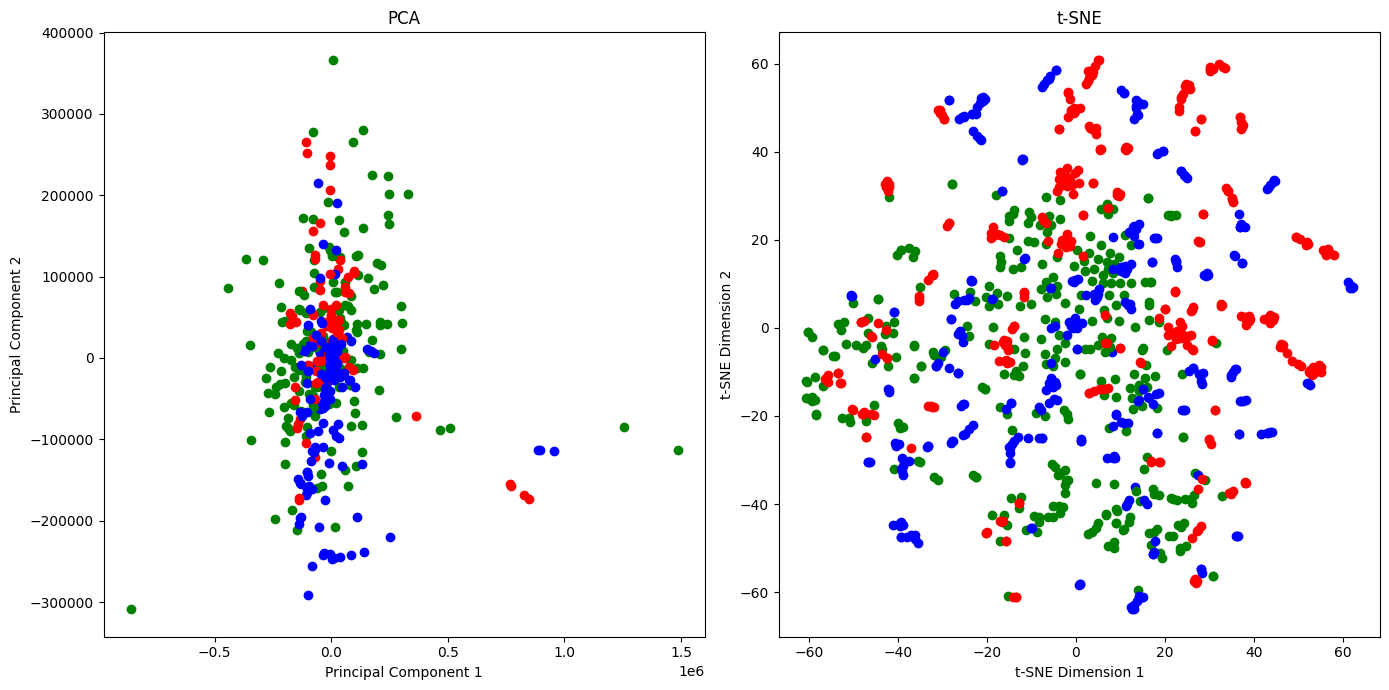

In [ ]:
original = m.remove_non_numeric_columns(dataset)
original_age = dataset["Age"]
#original.drop(columns=["Age"], inplace=True)
original["Class"]=["original"]*len(original)
result["Class"]=["modified"]*len(features)




plot_fake_data(result)

/tmp/ipykernel_32098/226533491.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  both_df["Age"] = both_df["Age"].replace("Old", 80)


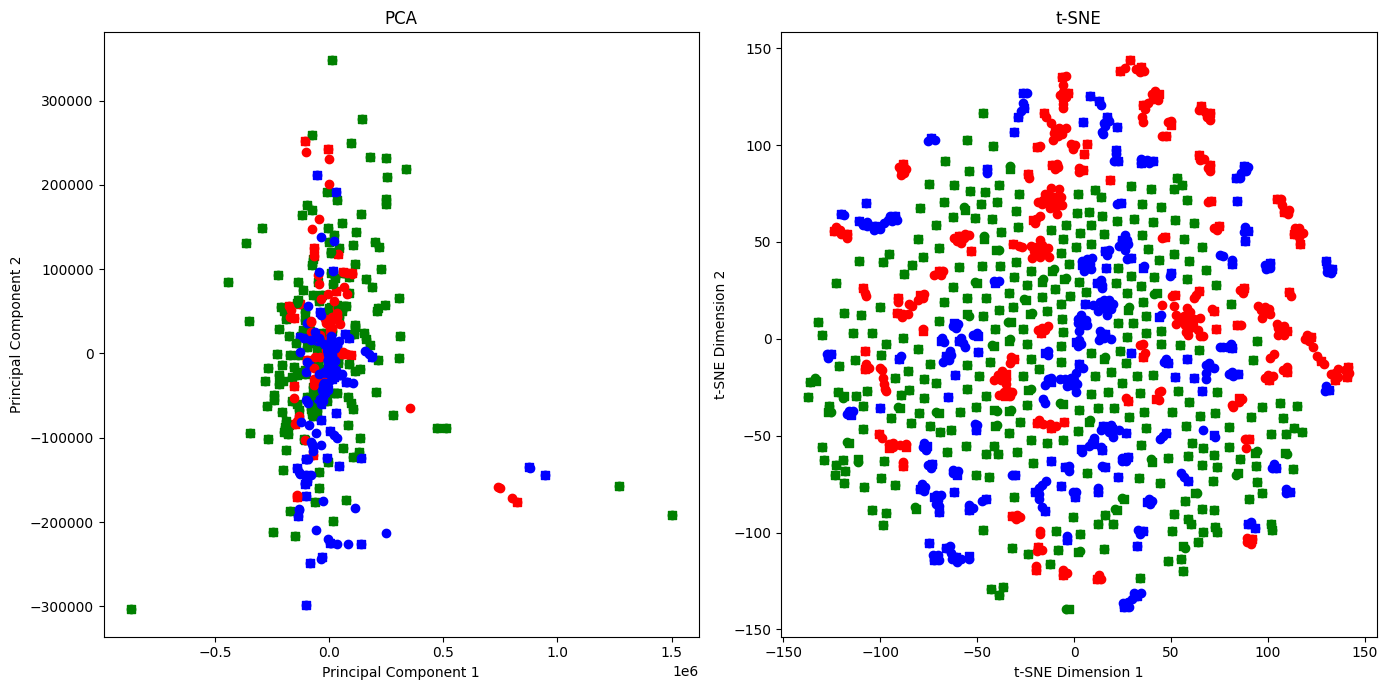

In [ ]:
# replace all "young" with 10, "middle" with 50 and "old" with 80
both_df = pd.concat([original, result])
both_df["Age"] = both_df["Age"].replace("Young", 20)
both_df["Age"] = both_df["Age"].replace("MiddleAge", 50)
both_df["Age"] = both_df["Age"].replace("Old", 80)
labels = ['Young', 'MiddleAge', 'Old']
# Define the age ranges for each category
bins = [18, 35, 65, float('inf')]
# Map the age numeric value to category label
both_df["Age"] = pd.cut(both_df['Age'], bins=bins, labels=labels, right=False)
both_df["Age"].value_counts()
both_df.dropna(inplace=True)
plot_fake_data(both_df)
#result[result["Class"]=="original"]
#both_df["Age"]

In [ ]:
both_df["Age"].value_counts()

Age
MiddleAge    642
Young        437
Old          406
Name: count, dtype: int64

In [ ]:
weights = get_feature_randomforest(both_df)
weights

Selected Features: [28, 29, 158, 191, 247, 249, 943, 960, 976, 1210, 1238, 1375, 1693, 1815, 1962, 2049, 2059, 2175, 2188, 2231, 2307, 2329, 2334, 2479, 2483, 2489, 2768, 2975, 3831, 4045, 4310, 4362, 4502, 4606, 4692, 5234, 5287, 5580, 5938, 6067, 6079, 6142, 6489, 6661, 6822, 7294, 7847, 7910, 7992, 8318, 8343, 8511, 8526, 8824, 8984, 9026, 9035, 9069, 9070, 9099, 9105, 9120, 9166, 9330, 9410, 9467, 9604, 9678, 9738, 9903, 10227, 10440, 10511, 10604, 10633, 10669, 10828, 11096, 11283, 11530, 12044, 12186, 12387, 12690, 13355, 13443, 13529, 13670, 13823, 14008, 14108, 14262, 14320, 14439, 14591, 14695, 15027, 15315, 15441, 15694, 15861, 16048, 16220, 16601, 16736, 16864, 17107, 17108, 17120, 17161, 17286, 17399, 17487, 17502, 17573, 17721, 17810, 17876, 18178, 18224, 18525, 18590, 18819, 18839, 19081, 19097, 19132, 19164, 19213, 19662, 19739, 20189, 20256, 20682, 20743, 20747, 20873, 20940, 20962, 21036, 21084, 21100, 21104, 21164, 21227, 21474, 21489, 21542, 21570, 21671, 21786, 2181

,coef
0.007291,Z99714
0.000000,Z98950
0.000000,Z98884
0.000000,Z98752
0.000000,Z98751
...,...
0.000000,AA001287
0.000000,AA001203
0.000000,AA001150
0.000000,AA001052
